<a href="https://colab.research.google.com/github/hafzawaqas2004/CSCE155-C-Lab03/blob/master/Lab_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1**

In [32]:
from collections import deque

# Tree using numbers
tree = {
    1: [2, 3],
    2: [4, 5],
    3: [6, 7],
    4: [],
    5: [],
    6: [],
    7: []
}

# Breadth-First Search
def bfs(tree, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        visited.append(node)
        queue.extend(tree[node])

    return visited

# Depth-First Search
def dfs(tree, node, visited=None):
    if visited is None:
        visited = []

    visited.append(node)

    for child in tree[node]:
        dfs(tree, child, visited)

    return visited

print("BFS Traversal:", bfs(tree, 1))
print("DFS Traversal:", dfs(tree, 1))

BFS Traversal: [1, 2, 3, 4, 5, 6, 7]
DFS Traversal: [1, 2, 4, 5, 3, 6, 7]


**part 2 (graph)**

In [33]:
from collections import deque

# Graph (same structure as diagram)
graph = {
    1: [2, 4],
    2: [1, 3, 5],
    3: [2],
    4: [1],
    5: [2]
}

# ---------------- BFS ----------------
def bfs(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])

    return visited


# ---------------- DFS ----------------
def dfs(graph, node, visited=None):
    if visited is None:
        visited = []

    visited.append(node)

    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)

    return visited


print("BFS Traversal:", bfs(graph, 1))
print("DFS Traversal:", dfs(graph, 1))

BFS Traversal: [1, 2, 4, 3, 5]
DFS Traversal: [1, 2, 3, 5, 4]


**TASK 2**


Part 1 Done: datasets created

RESULT TABLE:
   Input Size  BFS Time (sec)  DFS Time (sec)
0        1000        0.000420        0.000244
1       40000        0.025901        0.009203
2       80000        0.051242        0.020143
3      200000        0.130837        0.101249
4     1000000        0.653127        0.703449


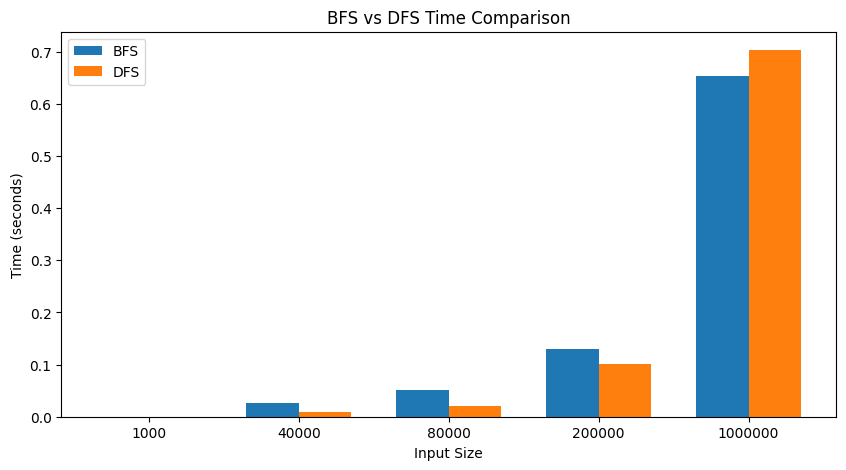

In [34]:
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#  PART 1: Generate datasets
sizes = [1000, 40000, 80000, 200000, 1000000]

datasets = {}

for n in sizes:
    arr = list(range(n))
    random.shuffle(arr)
    datasets[n] = arr

print("Part 1 Done: datasets created")

#  BFS FUNCTION
def bfs(arr, goal):
    queue = deque([0])
    visited = set()

    while queue:
        i = queue.popleft()

        if i in visited:
            continue

        visited.add(i)

        if arr[i] == goal:
            return True

        left = 2 * i + 1
        right = 2 * i + 2

        if left < len(arr):
            queue.append(left)
        if right < len(arr):
            queue.append(right)

    return False

#  DFS FUNCTION

def dfs(arr, i, goal, visited):
    if i >= len(arr) or i in visited:
        return False

    visited.add(i)

    if arr[i] == goal:
        return True

    return (
        dfs(arr, 2 * i + 1, goal, visited) or
        dfs(arr, 2 * i + 2, goal, visited)
    )

#  PART 2 + 3: TIME CALCULATION

bfs_times = []
dfs_times = []

for n in sizes:

    arr = datasets[n]

     # PART 3: Goal selection

    goal = arr[len(arr) - 220]

    # BFS time
    start = time.time()
    bfs(arr, goal)
    bfs_times.append(time.time() - start)

    # DFS time
    start = time.time()
    dfs(arr, 0, goal, set())
    dfs_times.append(time.time() - start)

#  PART 4: DATAFRAME

df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time (sec)": bfs_times,
    "DFS Time (sec)": dfs_times
})

print("\nRESULT TABLE:")
print(df)

#  PART 5: BAR CHART

x = np.arange(len(sizes))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, bfs_times, width, label="BFS")
plt.bar(x + width/2, dfs_times, width, label="DFS")

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Comparison")

plt.xticks(x, sizes)

plt.legend()
plt.show()

**TASK 3**

In [35]:
from collections import deque

# 1. Define the Graph based on your instructions
graph = {
    'Islamabad': ['Rawalpindi', 'Lahore', 'Peshawar'],
    'Rawalpindi': ['Islamabad', 'Peshawar', 'Quetta'],
    'Peshawar': ['Islamabad', 'Rawalpindi', 'Quetta'],
    'Lahore': ['Islamabad', 'Multan', 'Quetta'],
    'Multan': ['Lahore', 'Karachi', 'Quetta'],
    'Quetta': ['Rawalpindi', 'Peshawar', 'Multan', 'Karachi'],
    'Karachi': ['Multan', 'Quetta']
}

def find_shortest_path_bfs(graph, start, goal):
    # Queue stores the path we have traveled so far
    queue = deque([[start]])
    visited = {start}

    while queue:
        # Get the first path from the queue
        path = queue.popleft()
        # Get the last city in that path
        city = path[-1]

        # If we reached Karachi, return the path
        if city == goal:
            return path

        # Check neighbors
        for neighbor in graph.get(city, []):
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

# 2. Execute and Print Output
result = find_shortest_path_bfs(graph, 'Islamabad', 'Karachi')

print("Shortest Route using BFS:")
print(" -> ".join(result))

Shortest Route using BFS:
Islamabad -> Rawalpindi -> Quetta -> Karachi
